In [1]:
import pandas as pd
import numpy as np

In [2]:
loops_genexp=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/loops_with_gene_info_genelevel_gtfgencode.csv", sep=",")
loops_genexp

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,...,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3,anchor1_id,anchor2_id,cre_categorization,gene_id
0,8,8,8,8,chr1,6105000,6110000,chr1,6240000,6245000,...,NaN,NaN,0.173772,shared_2.5kb,shared_10kb,shared_0kb,anchor1_8,anchor2_8,promoter-enhancer,RNF207
1,29,29,29,29,chr1,9782500,9787500,chr1,9862500,9867500,...,0.167823,-0.145121,0.051565,shared_2.5kb,shared_10kb,shared_0kb,anchor1_29,anchor2_29,enhancer-enhancer,CLSTN1
2,71,71,71,71,chr1,21222500,21227500,chr1,21572500,21577500,...,-0.006993,0.054035,0.057613,shared_2.5kb,shared_10kb,shared_0kb,anchor1_71,anchor2_71,enhancer-other,ECE1
3,77,77,77,77,chr1,22665000,22670000,chr1,22960000,22965000,...,-0.028926,0.044354,0.074445,shared_2.5kb,shared_10kb,shared_0kb,anchor1_77,anchor2_77,promoter-enhancer,EPHB2
4,78,78,78,78,chr1,22672500,22677500,chr1,22882500,22887500,...,-0.028926,-0.013898,0.080946,shared_2.5kb,shared_10kb,shared_0kb,anchor1_78,anchor2_78,enhancer-enhancer,EPHB2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,32165,32165,32165,32165,chr7,51412500,51417500,chr7,55602500,55607500,...,0.047841,0.067683,0.035898,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32165,anchor2_32165,other-other,EGFR
1280,32208,32208,32208,32208,chr8,94812500,94817500,chr8,95022500,95027500,...,0.049483,-0.119102,0.040971,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32208,anchor2_32208,promoter-enhancer,CCNE2
1281,32213,32213,32213,32213,chr8,122735000,122740000,chr8,123060000,123065000,...,-0.049312,-0.056527,0.039866,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32213,anchor2_32213,enhancer-enhancer,ZHX2
1282,32230,32230,32230,32230,chr9,33582500,33587500,chr9,38552500,38557500,...,0.042401,-0.051918,0.024280,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32230,anchor2_32230,other-other,TPM2


In [3]:
# easy func
def compartment_switch(ctrl, rbp1):
    mask = ctrl.notna() & rbp1.notna()
    return mask & (np.sign(ctrl) != np.sign(rbp1))

In [4]:
# For anchor 1
loops_genexp["switch_anchor1"] = compartment_switch(
    loops_genexp["E1_anchor1_ctrl"], 
    loops_genexp["E1_anchor1_rbp1"]
)

# For anchor 2
loops_genexp["switch_anchor2"] = compartment_switch(
    loops_genexp["E1_anchor2_ctrl"], 
    loops_genexp["E1_anchor2_rbp1"]
)

In [5]:
loops_genexp["switch_anchor1"].sum()

40

In [6]:
loops_genexp["switch_anchor2"].sum()

46

In [7]:
loops_genexp[loops_genexp["switch_anchor1"]]

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,...,ATAC_signal,status_slop,status_slop2,status_slop3,anchor1_id,anchor2_id,cre_categorization,gene_id,switch_anchor1,switch_anchor2
12,354,354,354,354,chr1,119370000,119375000,chr1,119675000,119680000,...,0.060593,shared_2.5kb,shared_10kb,shared_0kb,anchor1_354,anchor2_354,enhancer-enhancer,PHGDH,True,False
42,857,857,857,857,chr10,69232500,69237500,chr10,69512500,69517500,...,0.046130,shared_2.5kb,shared_10kb,shared_0kb,anchor1_857,anchor2_857,promoter-other,HK1,True,False
113,2536,2536,2536,2536,chr15,98780000,98785000,chr15,98895000,98900000,...,0.038336,shared_2.5kb,shared_10kb,shared_0kb,anchor1_2536,anchor2_2536,enhancer-enhancer,IGF1R,True,False
156,3237,3237,3237,3237,chr19,46755000,46760000,chr19,46990000,46995000,...,0.040112,shared_2.5kb,shared_10kb,shared_0kb,anchor1_3237,anchor2_3237,enhancer-enhancer,SLC1A5,True,False
205,4256,4256,4256,4256,chr22,39012500,39017500,chr22,39122500,39127500,...,0.069759,shared_2.5kb,shared_10kb,shared_0kb,anchor1_4256,anchor2_4256,promoter-enhancer,APOBEC3F,True,False
225,4714,4714,4714,4714,chr3,156150000,156155000,chr3,157085000,157090000,...,0.043198,shared_2.5kb,shared_10kb,lost_0kb,anchor1_4714,anchor2_4714,promoter-enhancer,"LEKR1,LINC00880",True,False
253,5125,5125,5125,5125,chr4,112630000,112635000,chr4,112940000,112945000,...,0.068393,shared_2.5kb,shared_10kb,lost_0kb,anchor1_5125,anchor2_5125,enhancer-enhancer,ANK2,True,True
364,8160,8160,8160,8160,chr10,4812500,4817500,chr10,5622500,5627500,...,0.033743,lost_2.5kb,shared_10kb,lost_0kb,anchor1_8160,anchor2_8160,enhancer-enhancer,AKR1C3,True,False
365,8161,8161,8161,8161,chr10,4832500,4837500,chr10,5102500,5107500,...,0.042403,lost_2.5kb,shared_10kb,lost_0kb,anchor1_8161,anchor2_8161,enhancer-enhancer,AKR1C3,True,False
389,8551,8551,8551,8551,chr11,9272500,9277500,chr11,9442500,9447500,...,0.026365,lost_2.5kb,shared_10kb,lost_0kb,anchor1_8551,anchor2_8551,enhancer-other,SNORA23,True,False


In [8]:
loops_genexp[loops_genexp["switch_anchor2"]]

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,...,ATAC_signal,status_slop,status_slop2,status_slop3,anchor1_id,anchor2_id,cre_categorization,gene_id,switch_anchor1,switch_anchor2
155,3236,3236,3236,3236,chr19,46272500,46277500,chr19,47392500,47397500,...,0.034381,shared_2.5kb,shared_10kb,shared_0kb,anchor1_3236,anchor2_3236,enhancer-other,"SLC1A5,ZC3H4",False,True
158,3240,3240,3240,3240,chr19,47075000,47080000,chr19,47125000,47130000,...,0.036523,shared_2.5kb,shared_10kb,shared_0kb,anchor1_3240,anchor2_3240,enhancer-enhancer,ZC3H4,False,True
162,3267,3267,3267,3267,chr19,55140000,55145000,chr19,55500000,55505000,...,0.074504,shared_2.5kb,shared_10kb,shared_0kb,anchor1_3267,anchor2_3267,enhancer-enhancer,KMT5C,False,True
253,5125,5125,5125,5125,chr4,112630000,112635000,chr4,112940000,112945000,...,0.068393,shared_2.5kb,shared_10kb,lost_0kb,anchor1_5125,anchor2_5125,enhancer-enhancer,ANK2,True,True
303,6969,6969,6969,6969,chr8,119262500,119267500,chr8,119432500,119437500,...,0.043282,lost_2.5kb,shared_10kb,lost_0kb,anchor1_6969,anchor2_6969,enhancer-other,CCN3,False,True
353,7948,7948,7948,7948,chr1,182960000,182965000,chr1,183230000,183235000,...,0.039645,lost_2.5kb,shared_10kb,lost_0kb,anchor1_7948,anchor2_7948,enhancer-enhancer,LAMC2,False,True
417,9897,9897,9897,9897,chr15,72730000,72735000,chr15,73270000,73275000,...,0.088285,lost_2.5kb,shared_10kb,lost_0kb,anchor1_9897,anchor2_9897,enhancer-enhancer,NEO1,False,True
418,9899,9899,9899,9899,chr15,74370000,74375000,chr15,74490000,74495000,...,0.042100,lost_2.5kb,shared_10kb,lost_0kb,anchor1_9899,anchor2_9899,promoter-promoter,SEMA7A,True,True
423,9922,9922,9922,9922,chr15,80780000,80785000,chr15,80855000,80860000,...,0.052084,lost_2.5kb,shared_10kb,lost_0kb,anchor1_9922,anchor2_9922,enhancer-enhancer,CEMIP,False,True
458,10736,10736,10736,10736,chr19,41640000,41645000,chr19,41800000,41805000,...,0.083733,lost_2.5kb,shared_10kb,lost_0kb,anchor1_10736,anchor2_10736,enhancer-enhancer,CEACAM5,False,True


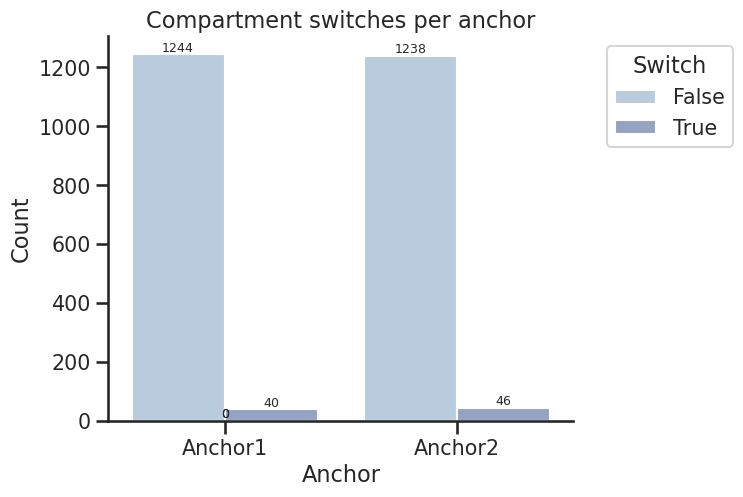

/tmp/ipykernel_270184/1087972689.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loops_genexp, x="any_switch", y="log2FC",


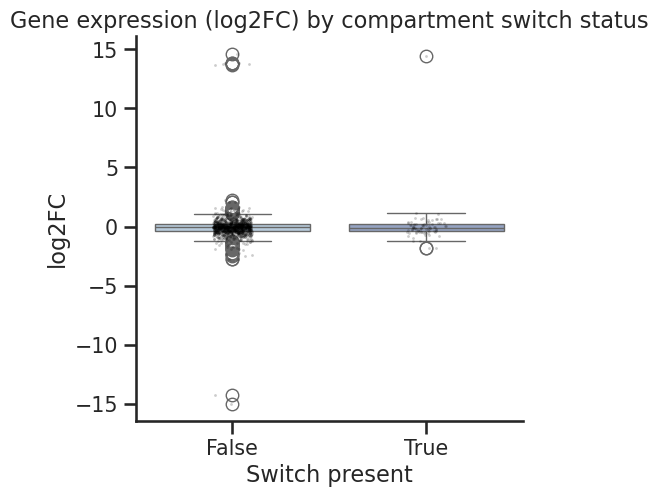

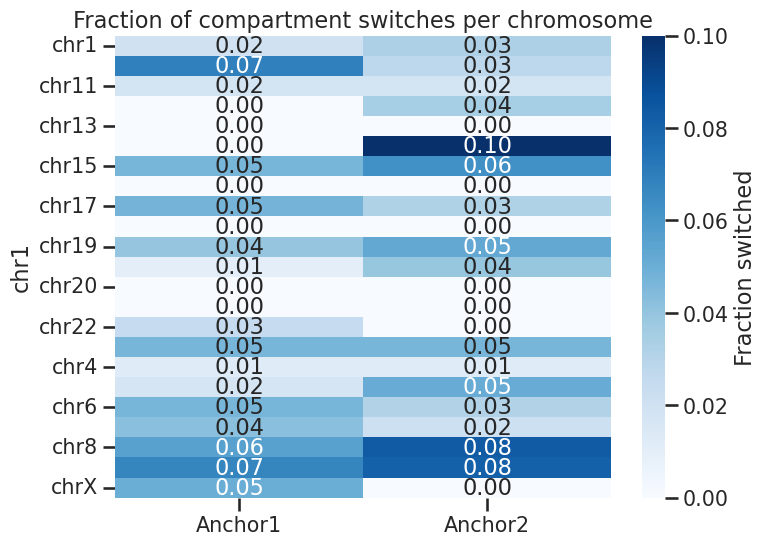

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Set style ===
custom_palette = ["#b3cde3", "#8da0cb"]
sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

# ==========================================================
# 1. Barplot: number of switched vs non-switched anchors
# ==========================================================
switch_counts = pd.DataFrame({
    "Anchor1": loops_genexp["switch_anchor1"].value_counts(),
    "Anchor2": loops_genexp["switch_anchor2"].value_counts()
}).T.reset_index().melt(id_vars="index", var_name="Switch", value_name="Count")

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=switch_counts, x="index", y="Count", hue="Switch", palette=custom_palette, ax=ax)
ax.set_title("Compartment switches per anchor")
ax.set_xlabel("Anchor")
ax.set_ylabel("Count")
ax.legend(title="Switch", bbox_to_anchor=(1.05,1), loc="upper left")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.show()

# ==========================================================
# 2. Boxplot: expression distribution (switched vs non-switched)
# ==========================================================
# Define "any switch" as union of anchor1 and anchor2
loops_genexp["any_switch"] = loops_genexp[["switch_anchor1","switch_anchor2"]].any(axis=1)

fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(data=loops_genexp, x="any_switch", y="log2FC",
            palette=custom_palette, ax=ax)
sns.stripplot(data=loops_genexp, x="any_switch", y="log2FC",
              color="black", alpha=0.2, size=2, ax=ax)
ax.set_title("Gene expression (log2FC) by compartment switch status")
ax.set_xlabel("Switch present")
ax.set_ylabel("log2FC")
plt.show()

# ==========================================================
# 3. Heatmap: fraction of switches per chromosome
# ==========================================================
# Assuming you have "chrom" column
chrom_switch = (loops_genexp.groupby("chr1")[["switch_anchor1","switch_anchor2"]]
                .mean()  # fraction of True per chromosome
                .rename(columns={"switch_anchor1":"Anchor1","switch_anchor2":"Anchor2"}))

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(chrom_switch, cmap="Blues", annot=True, fmt=".2f", cbar_kws={'label': 'Fraction switched'}, ax=ax)
ax.set_title("Fraction of compartment switches per chromosome")
plt.show()


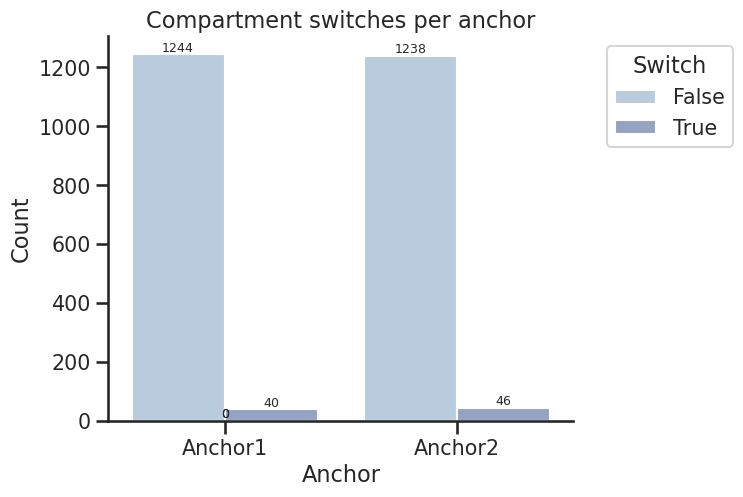

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Prepare data ===
switch_counts = pd.DataFrame({
    "Anchor1": loops_genexp["switch_anchor1"].value_counts(),
    "Anchor2": loops_genexp["switch_anchor2"].value_counts()
}).T.reset_index().melt(id_vars="index", var_name="Switch", value_name="Count")

# Convert Switch to string (avoids 0.00 tick issue)
switch_counts["Switch"] = switch_counts["Switch"].astype(str)

# === Plot ===
custom_palette = ["#b3cde3", "#8da0cb"]

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=switch_counts, x="index", y="Count", hue="Switch",
            palette=custom_palette, ax=ax)

# Titles and labels
ax.set_title("Compartment switches per anchor")
ax.set_xlabel("Anchor")
ax.set_ylabel("Count")

# Legend
ax.legend(title="Switch", bbox_to_anchor=(1.05,1), loc="upper left")

# Annotate values on bars
for p in ax.patches:
    value = int(p.get_height())
    ax.annotate(value,
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.show()

In [11]:
# === Prepare data ===
# Anchor1
df1 = loops_genexp[["switch_anchor1", "gene_log2fc"]].rename(
    columns={"switch_anchor1": "Switch"}
)
df1["Anchor"] = "Anchor1"

# Anchor2
df2 = loops_genexp[["switch_anchor2", "gene_log2fc"]].rename(
    columns={"switch_anchor2": "Switch"}
)
df2["Anchor"] = "Anchor2"

# Combine
df_fc = pd.concat([df1, df2], ignore_index=True)
df_fc["Switch"] = df_fc["Switch"].astype(str)  # avoid numeric 0.0/1.0 issue

# === Plot distributions ===
custom_palette = ["#b3cde3", "#8da0cb"]

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=df_fc, x="Anchor", y="gene_log2fc", hue="Switch",
            palette=custom_palette, ci="sd", ax=ax)

ax.set_title("Average gene log2FC by compartment switch")
ax.set_xlabel("Anchor")
ax.set_ylabel("Mean log2FC ± SD")
ax.legend(title="Switch", bbox_to_anchor=(1.05,1), loc="upper left")

plt.show()


KeyError: "['gene_log2fc'] not in index"

In [ ]:
loops_genexp.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'chr1',
       'start1', 'end1', 'chr2', 'start2', 'end2', 'status', 'ctrl_signal',
       'rbp1_signal', 'log2FC', 'log2FC_clipped', 'condition', 'distance',
       'loop_id', 'comp_switch_A1', 'comp_switch_A2', 'loop_class', 'source',
       'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal',
       'GC_mean', 'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1',
       'E1_anchor2_ctrl', 'E1_anchor2_rbp1', 'delta_E1_anchor1',
       'delta_E1_anchor2', 'ATAC_signal', 'status_slop', 'status_slop2',
       'status_slop3', 'anchor1_id', 'anchor2_id', 'cre_categorization',
       'gene_id', 'switch_anchor1', 'switch_anchor2', 'any_switch'],
      dtype='object')

In [ ]:
loops_genexp.status

0       shared
1       shared
2       shared
3       shared
4       shared
         ...  
1279    gained
1280    gained
1281    gained
1282    gained
1283    gained
Name: status, Length: 1284, dtype: object

In [19]:
up_genes = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt",
    sep="\t"
)
up_genes["de_status"] = "UP"
down_genes = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt",
    sep="\t"
)
down_genes["de_status"] = "DOWN"

print(up_genes.columns)

Index(['ensembl_id', 'ensembl', 'log2FC', 'hgnc_symbol', 'de_status'], dtype='object')


In [20]:
de_all = pd.concat([up_genes, down_genes], ignore_index=True)
de_all

,ensembl_id,ensembl,log2FC,hgnc_symbol,de_status
0,ENSG00000005339,ENSG00000005339.15,0.653104,CREBBP,UP
1,ENSG00000010292,ENSG00000010292.13,0.711214,NCAPD2,UP
2,ENSG00000011347,ENSG00000011347.10,0.696552,SYT7,UP
3,ENSG00000013288,ENSG00000013288.9,0.703644,MAN2B2,UP
4,ENSG00000026508,ENSG00000026508.21,0.749793,CD44,UP
...,...,...,...,...,...
299,ENSG00000290076,ENSG00000290076.1,-0.690556,ENSG00000290076,DOWN
300,ENSG00000290548,ENSG00000290548.2,-0.628500,ENSG00000290548,DOWN
301,ENSG00000291100,ENSG00000291100.2,-0.647279,ENSG00000291100,DOWN
302,ENSG00000291117,ENSG00000291117.2,-0.658197,ENSG00000291117,DOWN


In [18]:
loops_genexp

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,...,status_slop,status_slop2,status_slop3,anchor1_id,anchor2_id,cre_categorization,gene_id,switch_anchor1,switch_anchor2,any_switch
0,8,8,8,8,chr1,6105000,6110000,chr1,6240000,6245000,...,shared_2.5kb,shared_10kb,shared_0kb,anchor1_8,anchor2_8,promoter-enhancer,RNF207,False,False,False
1,29,29,29,29,chr1,9782500,9787500,chr1,9862500,9867500,...,shared_2.5kb,shared_10kb,shared_0kb,anchor1_29,anchor2_29,enhancer-enhancer,CLSTN1,False,False,False
2,71,71,71,71,chr1,21222500,21227500,chr1,21572500,21577500,...,shared_2.5kb,shared_10kb,shared_0kb,anchor1_71,anchor2_71,enhancer-other,ECE1,False,False,False
3,77,77,77,77,chr1,22665000,22670000,chr1,22960000,22965000,...,shared_2.5kb,shared_10kb,shared_0kb,anchor1_77,anchor2_77,promoter-enhancer,EPHB2,False,False,False
4,78,78,78,78,chr1,22672500,22677500,chr1,22882500,22887500,...,shared_2.5kb,shared_10kb,shared_0kb,anchor1_78,anchor2_78,enhancer-enhancer,EPHB2,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,32165,32165,32165,32165,chr7,51412500,51417500,chr7,55602500,55607500,...,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32165,anchor2_32165,other-other,EGFR,False,False,False
1280,32208,32208,32208,32208,chr8,94812500,94817500,chr8,95022500,95027500,...,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32208,anchor2_32208,promoter-enhancer,CCNE2,False,False,False
1281,32213,32213,32213,32213,chr8,122735000,122740000,chr8,123060000,123065000,...,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32213,anchor2_32213,enhancer-enhancer,ZHX2,False,False,False
1282,32230,32230,32230,32230,chr9,33582500,33587500,chr9,38552500,38557500,...,gained_2.5kb,gained_10kb,gained_0kb,anchor1_32230,anchor2_32230,other-other,TPM2,False,True,True


In [21]:
merged_degs = loops_genexp.merge(
    de_all[["hgnc_symbol","log2FC","de_status"]],
    left_on="gene_id", right_on="hgnc_symbol", how="inner"
)
merged_degs

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,...,anchor1_id,anchor2_id,cre_categorization,gene_id,switch_anchor1,switch_anchor2,any_switch,hgnc_symbol,log2FC_y,de_status
0,8,8,8,8,chr1,6105000,6110000,chr1,6240000,6245000,...,anchor1_8,anchor2_8,promoter-enhancer,RNF207,False,False,False,RNF207,-0.732746,DOWN
1,29,29,29,29,chr1,9782500,9787500,chr1,9862500,9867500,...,anchor1_29,anchor2_29,enhancer-enhancer,CLSTN1,False,False,False,CLSTN1,0.623634,UP
2,71,71,71,71,chr1,21222500,21227500,chr1,21572500,21577500,...,anchor1_71,anchor2_71,enhancer-other,ECE1,False,False,False,ECE1,0.742707,UP
3,77,77,77,77,chr1,22665000,22670000,chr1,22960000,22965000,...,anchor1_77,anchor2_77,promoter-enhancer,EPHB2,False,False,False,EPHB2,0.881383,UP
4,78,78,78,78,chr1,22672500,22677500,chr1,22882500,22887500,...,anchor1_78,anchor2_78,enhancer-enhancer,EPHB2,False,False,False,EPHB2,0.881383,UP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,32165,32165,32165,32165,chr7,51412500,51417500,chr7,55602500,55607500,...,anchor1_32165,anchor2_32165,other-other,EGFR,False,False,False,EGFR,0.760964,UP
1196,32208,32208,32208,32208,chr8,94812500,94817500,chr8,95022500,95027500,...,anchor1_32208,anchor2_32208,promoter-enhancer,CCNE2,False,False,False,CCNE2,-0.729380,DOWN
1197,32213,32213,32213,32213,chr8,122735000,122740000,chr8,123060000,123065000,...,anchor1_32213,anchor2_32213,enhancer-enhancer,ZHX2,False,False,False,ZHX2,0.754174,UP
1198,32230,32230,32230,32230,chr9,33582500,33587500,chr9,38552500,38557500,...,anchor1_32230,anchor2_32230,other-other,TPM2,False,True,True,TPM2,-1.544577,DOWN


In [22]:
from scipy.stats import fisher_exact

up   = merged_degs[merged_degs["de_status"]=="UP"]
down = merged_degs[merged_degs["de_status"]=="DOWN"]

up_switch    = up["any_switch"].sum()
up_no_switch = (~up["any_switch"]).sum()

down_switch    = down["any_switch"].sum()
down_no_switch = (~down["any_switch"]).sum()

table = [[up_switch, up_no_switch],
         [down_switch, down_no_switch]]

print(table)

odds, p = fisher_exact(table)
print(f"Odds ratio={odds:.2f}, p={p:.3e}")

[[62, 908], [12, 218]]
Odds ratio=1.24, p=6.471e-01


In [23]:
## My basic idea was to see how many loops associated with DEGs were undergoing a switch...But I want it per DEG.

# Collapse per gene: flag if any loop for that gene hits a compartment switch
deg_switch_status = (
    merged_degs
    .groupby(["gene_id","de_status"])["any_switch"]
    .any()
    .reset_index()
)

# Counts of UP vs DOWN genes with at least one switched loop
counts = deg_switch_status.groupby(["de_status","any_switch"])["gene_id"].nunique().unstack(fill_value=0)
print(counts)

# Fisher test UP vs DOWN per gene
up_switch    = ((deg_switch_status["de_status"]=="UP") & (deg_switch_status["any_switch"])).sum()
up_no_switch = ((deg_switch_status["de_status"]=="UP") & (~deg_switch_status["any_switch"])).sum()
down_switch  = ((deg_switch_status["de_status"]=="DOWN") & (deg_switch_status["any_switch"])).sum()
down_no_switch = ((deg_switch_status["de_status"]=="DOWN") & (~deg_switch_status["any_switch"])).sum()

from scipy.stats import fisher_exact
table = [[up_switch, up_no_switch],
         [down_switch, down_no_switch]]

print("Contingency (per DEG):", table)
odds, p = fisher_exact(table)
print(f"Odds ratio={odds:.2f}, p={p:.3e}")


any_switch  False  True 
de_status               
DOWN           38      8
UP            129     51
Contingency (per DEG): [[51, 129], [8, 38]]
Odds ratio=1.88, p=1.870e-01


In [ ]:
### DOWN: 38 (no switch) + 8 (switch)   = 46
### UP:   129 (no switch) + 51 (switch) = 180

# On a per gene basis, more UP-DEGs than DOWN-DEGs are associated with compartment switches (28% vs 17%).

# The enrichment is suggestive (odds ratio ~2) but not significant at conventional thresholds.
